Jumlah data per label:
   class_name  count  percentage
0  Recyclable   9999       37.70
1  Electronic   3959       14.93
2     Organic  12567       47.38

Ringkasan:
Min count: 3959
Max count: 12567
Imbalance ratio (max/min): 3.17
Hasil: dataset mengalami class imbalance yang signifikan.


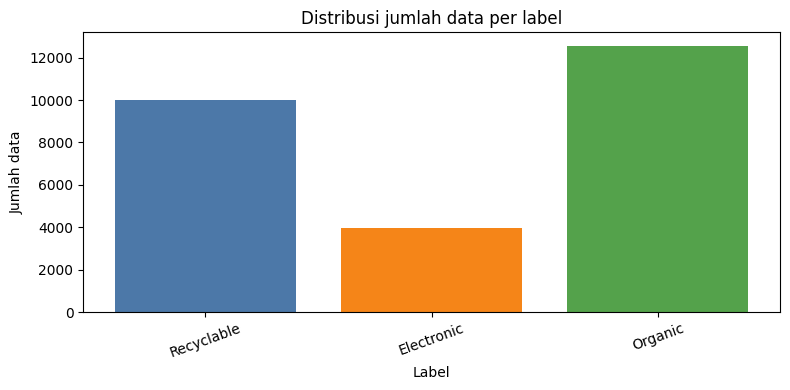

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import os

# Path folder train (auto-detect dari working directory)
train_dir = Path(os.getcwd()) / "train"
if not train_dir.exists():
    train_dir = Path(os.getcwd()).parent / "train"

# Ambil semua subfolder kelas
class_dirs = sorted([p for p in train_dir.iterdir() if p.is_dir()])

def count_images(folder):
    return sum(1 for p in folder.rglob("*") if p.is_file())

# Buat dataframe jumlah data per label
data = []
for folder in class_dirs:
    data.append({
        "label": folder.name,
        "count": count_images(folder)
    })

df = pd.DataFrame(data)

# Bersihkan nama label agar lebih rapi
df["class_name"] = df["label"].str.split("_", n=1).str[1].fillna(df["label"])
df["percentage"] = (df["count"] / df["count"].sum() * 100).round(2)

print("Jumlah data per label:")
print(df[["class_name", "count", "percentage"]])

# Cek tingkat imbalance
min_count = df["count"].min()
max_count = df["count"].max()
imbalance_ratio = max_count / min_count if min_count > 0 else float("inf")

print("\nRingkasan:")
print(f"Min count: {min_count}")
print(f"Max count: {max_count}")
print(f"Imbalance ratio (max/min): {imbalance_ratio:.2f}")

if imbalance_ratio < 1.2:
    print("Hasil: dataset cenderung seimbang.")
elif imbalance_ratio < 2:
    print("Hasil: dataset sedikit tidak seimbang.")
else:
    print("Hasil: dataset mengalami class imbalance yang signifikan.")

# Visualisasi distribusi
plt.figure(figsize=(8, 4))
plt.bar(df["class_name"], df["count"], color=["#4C78A8", "#F58518", "#54A24B"])
plt.title("Distribusi jumlah data per label")
plt.xlabel("Label")
plt.ylabel("Jumlah data")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


In [2]:
from pathlib import Path
import hashlib
from PIL import Image

train_dir = Path("train")
class_dirs = sorted([p for p in train_dir.iterdir() if p.is_dir()])
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def pixel_signature(path):
    img = Image.open(path).convert("RGB")
    width, height = img.size
    return hashlib.sha256(f"{width}x{height}".encode() + b"|" + img.tobytes()).hexdigest()

for class_dir in class_dirs:
    image_paths = sorted([
        p for p in class_dir.rglob("*")
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS
    ])

    signature_map = {}
    for p in image_paths:
        try:
            sig = pixel_signature(p)
            signature_map.setdefault(sig, []).append(p)
        except Exception as e:
            print(f"Lewati {p.name}: {e}")

    duplicate_groups = {
        sig: files for sig, files in signature_map.items() if len(files) > 1
    }

    print(f"\nKelas: {class_dir.name}")
    print(f"Total gambar: {len(image_paths)}")
    print(f"Jumlah unik berdasarkan piksel: {len(signature_map)}")

    if duplicate_groups:
        print("Ditemukan gambar yang sama persis:")
        for sig, files in duplicate_groups.items():
            print(" -", [f.name for f in files])
    else:
        print("Tidak ada gambar yang sama persis berdasarkan nilai piksel.")


Kelas: 0_Recyclable
Total gambar: 9999
Jumlah unik berdasarkan piksel: 9990
Ditemukan gambar yang sama persis:
 - ['R_1277.jpg', 'R_38.jpg']
 - ['R_8442.jpg', 'R_9284.jpg']
 - ['R_8486.jpg', 'R_9205.jpg']
 - ['R_8567.jpg', 'R_9471.jpg']
 - ['R_8577.jpg', 'R_9410.jpg']
 - ['R_8715.jpg', 'R_9275.jpg']
 - ['R_8721.jpg', 'R_9487.jpg']
 - ['R_8803.jpg', 'R_9412.jpg']
 - ['R_8805.jpg', 'R_9484.jpg']

Kelas: 1_Electronic
Total gambar: 3959
Jumlah unik berdasarkan piksel: 3929
Ditemukan gambar yang sama persis:
 - ['10.e-waste-pile.jpg', '13.e-waste-pile.jpg']
 - ['12.scrap-yard-electronic-waste-for-recycling-with-selective-focus-electronic-aluminium-waste-2BWXNJG.jpg', '5.scrap-yard-electronic-waste-for-recycling-with-selective-focus-electronic-aluminium-waste-2BWXNJG.jpg']
 - ['16.large-pile-of-e-waste-sadoff-e-recycling.jpeg', '8.large-pile-of-e-waste-sadoff-e-recycling.jpeg']
 - ['18.E-Waste_Landfill.jpg', '5.E-Waste_Landfill.jpg']
 - ['18.growing-problem-ewast.2e16d0ba.fill-1200x628.form

In [5]:
"""
EDA Properti Teknis Gambar
Big Data Challenge Satria Data 2026

Script ini digunakan untuk menganalisis properti teknis citra pada dataset
train (folder train dengan subfolder 0_Recyclable, 1_Electronic, 2_Organic).

Yang dianalisis:
1. Ukuran resolusi tiap citra (lebar dan tinggi)
2. Rasio aspek gambar
3. Format file (jpg, png, dll)
4. Mode warna (RGB, grayscale, RGBA, dll)

Hasil akhir berupa tabel ringkasan dan file CSV detail per gambar,
tanpa visualisasi interaktif.
"""

import os
from pathlib import Path
from collections import Counter
import pandas as pd
from PIL import Image

# ==== KONFIGURASI ====
train_dir = Path("train")  # Path folder train
OUTPUT_CSV = "eda_properti_teknis.csv"

CLASS_FOLDERS = {
    "0_Recyclable": "Recyclable",
    "1_Electronic": "Electronic",
    "2_Organic": "Organic",
}


def kumpulkan_data_properti(train_dir):
    """
    Membaca seluruh gambar pada tiap subfolder kelas,
    lalu mengumpulkan properti teknisnya.
    """
    hasil = []

    for folder_name, label in CLASS_FOLDERS.items():
        folder_path = Path(train_dir) / folder_name
        if not folder_path.exists():
            print(f"Peringatan: folder {folder_path} tidak ditemukan, dilewati.")
            continue

        file_list = [
            f for f in os.listdir(folder_path)
            if os.path.isfile(folder_path / f)
        ]

        for file_name in file_list:
            file_path = folder_path / file_name
            ekstensi = file_name.split(".")[-1].lower() if "." in file_name else "tanpa_ekstensi"

            try:
                with Image.open(file_path) as img:
                    lebar, tinggi = img.size
                    mode_warna = img.mode
                    rasio_aspek = round(lebar / tinggi, 3) if tinggi != 0 else None

                hasil.append({
                    "nama_file": file_name,
                    "label": label,
                    "lebar": lebar,
                    "tinggi": tinggi,
                    "rasio_aspek": rasio_aspek,
                    "format_file": ekstensi,
                    "mode_warna": mode_warna,
                    "status": "ok",
                })

            except Exception as e:
                hasil.append({
                    "nama_file": file_name,
                    "label": label,
                    "lebar": None,
                    "tinggi": None,
                    "rasio_aspek": None,
                    "format_file": ekstensi,
                    "mode_warna": None,
                    "status": f"gagal_dibaca: {e}",
                })

    return pd.DataFrame(hasil)


def ringkasan_per_kelas(df):
    """
    Menampilkan ringkasan statistik resolusi dan rasio aspek per kelas.
    """
    df_valid = df[df["status"] == "ok"]

    print("\n=== RINGKASAN RESOLUSI PER KELAS ===")
    ringkasan = df_valid.groupby("label").agg(
        jumlah_gambar=("nama_file", "count"),
        lebar_min=("lebar", "min"),
        lebar_max=("lebar", "max"),
        lebar_rata=("lebar", "mean"),
        tinggi_min=("tinggi", "min"),
        tinggi_max=("tinggi", "max"),
        tinggi_rata=("tinggi", "mean"),
        rasio_aspek_min=("rasio_aspek", "min"),
        rasio_aspek_max=("rasio_aspek", "max"),
        rasio_aspek_rata=("rasio_aspek", "mean"),
    ).round(2)

    print(ringkasan)
    return ringkasan


def ringkasan_format_dan_mode(df):
    """
    Menampilkan distribusi format file dan mode warna, keseluruhan dan per kelas.
    """
    print("\n=== DISTRIBUSI FORMAT FILE (KESELURUHAN) ===")
    print(df["format_file"].value_counts())

    print("\n=== DISTRIBUSI MODE WARNA (KESELURUHAN) ===")
    print(df["mode_warna"].value_counts())

    print("\n=== DISTRIBUSI MODE WARNA PER KELAS ===")
    print(df.groupby(["label", "mode_warna"]).size())

    print("\n=== DISTRIBUSI FORMAT FILE PER KELAS ===")
    print(df.groupby(["label", "format_file"]).size())


def cek_gambar_gagal_dibaca(df):
    """
    Menampilkan daftar file yang gagal dibaca atau corrupt.
    """
    df_gagal = df[df["status"] != "ok"]
    print(f"\n=== JUMLAH GAMBAR GAGAL DIBACA: {len(df_gagal)} ===")
    if len(df_gagal) > 0:
        print(df_gagal[["nama_file", "label", "status"]])
    return df_gagal


def cek_variasi_resolusi(df):
    """
    Mengecek seberapa banyak variasi ukuran resolusi unik yang ada,
    untuk membantu menentukan ukuran resize yang tepat.
    """
    df_valid = df[df["status"] == "ok"]
    kombinasi_ukuran = df_valid.groupby(["lebar", "tinggi"]).size().sort_values(ascending=False)

    print(f"\n=== JUMLAH KOMBINASI UKURAN UNIK: {kombinasi_ukuran.shape[0]} ===")
    print("10 ukuran paling sering muncul:")
    print(kombinasi_ukuran.head(10))


def main():
    df = kumpulkan_data_properti(train_dir)

    if df.empty:
        print("Tidak ada data yang berhasil dikumpulkan. Cek kembali path train_dir.")
        return

    df.to_csv(OUTPUT_CSV, index=False)
    print(f"Detail properti tiap gambar disimpan pada {OUTPUT_CSV}")

    ringkasan_per_kelas(df)
    ringkasan_format_dan_mode(df)
    cek_variasi_resolusi(df)
    cek_gambar_gagal_dibaca(df)


if __name__ == "__main__":
    main()

Detail properti tiap gambar disimpan pada eda_properti_teknis.csv

=== RINGKASAN RESOLUSI PER KELAS ===
            jumlah_gambar  lebar_min  lebar_max  lebar_rata  tinggi_min  \
label                                                                     
Electronic           3959        150       8000      604.72         113   
Organic             12567         51        600      260.31          69   
Recyclable           9999         56        569      242.28          88   

            tinggi_max  tinggi_rata  rasio_aspek_min  rasio_aspek_max  \
label                                                                   
Electronic        6000       515.12             0.29             4.00   
Organic            383       197.45             0.13             8.70   
Recyclable         346       211.66             0.16             6.47   

            rasio_aspek_rata  
label                         
Electronic              1.10  
Organic                 1.39  
Recyclable              1.21  

In [ ]:
# """
# EDA Sampel Visual per Kelas
# Big Data Challenge Satria Data 2026

# Script ini digunakan untuk menampilkan dan menyimpan sampel gambar acak
# dari tiap kelas (Recyclable, Electronic, Organic), sehingga bisa dilihat
# karakteristik visual masing masing kelas seperti latar belakang, warna
# dominan, dan bentuk objek.

# Output berupa file gambar grid (kolase) per kelas yang disimpan ke disk,
# bukan tampilan interaktif.
# """

# import os
# import random
# from pathlib import Path
# import math
# from PIL import Image

# # ==== KONFIGURASI ====
# train_dir = Path("train")  # Path folder train
# OUTPUT_DIR = "eda_sampel_visual"
# JUMLAH_SAMPEL = 12
# UKURAN_THUMBNAIL = 200
# SEED = 42

# CLASS_FOLDERS = {
#     "0_Recyclable": "Recyclable",
#     "1_Electronic": "Electronic",
#     "2_Organic": "Organic",
# }


# def ambil_sampel_acak(folder_path, jumlah):
#     """
#     Mengambil sejumlah nama file gambar secara acak dari sebuah folder.
#     """
#     file_list = [
#         f for f in os.listdir(folder_path)
#         if os.path.isfile(Path(folder_path) / f)
#     ]
#     random.seed(SEED)
#     jumlah_ambil = min(jumlah, len(file_list))
#     return random.sample(file_list, jumlah_ambil)


# def buat_grid_gambar(daftar_path_gambar, judul_kelas, ukuran_thumb, output_path):
#     """
#     Menggabungkan beberapa gambar menjadi satu grid dan menyimpannya sebagai file.
#     """
#     jumlah_gambar = len(daftar_path_gambar)
#     kolom = 4
#     baris = math.ceil(jumlah_gambar / kolom)

#     grid = Image.new(
#         "RGB",
#         (kolom * ukuran_thumb, baris * ukuran_thumb),
#         color=(255, 255, 255),
#     )

#     for idx, path_gambar in enumerate(daftar_path_gambar):
#         try:
#             with Image.open(path_gambar) as img:
#                 img_rgb = img.convert("RGB")
#                 img_rgb.thumbnail((ukuran_thumb, ukuran_thumb))

#                 thumb_canvas = Image.new("RGB", (ukuran_thumb, ukuran_thumb), color=(240, 240, 240))
#                 offset_x = (ukuran_thumb - img_rgb.width) // 2
#                 offset_y = (ukuran_thumb - img_rgb.height) // 2
#                 thumb_canvas.paste(img_rgb, (offset_x, offset_y))

#                 baris_idx = idx // kolom
#                 kolom_idx = idx % kolom
#                 grid.paste(thumb_canvas, (kolom_idx * ukuran_thumb, baris_idx * ukuran_thumb))

#         except Exception as e:
#             print(f"Gagal memproses {path_gambar}: {e}")

#     grid.save(output_path)
#     print(f"Grid sampel kelas {judul_kelas} disimpan pada {output_path}")


# def analisis_kemiripan_kandidat(train_dir):
#     """
#     Mencetak catatan manual mengenai potensi kemiripan visual antar kelas
#     yang perlu dicek langsung pada grid gambar yang dihasilkan.
#     """
#     print("\nCatatan pengecekan manual saat melihat grid gambar tiap kelas:")
#     print("1. Perhatikan apakah kabel pada kelas Electronic mirip warna dan bentuk dengan ranting pada kelas Organic")
#     print("2. Perhatikan apakah botol plastik bening pada kelas Recyclable mirip kaca atau layar pada kelas Electronic")
#     print("3. Perhatikan apakah gaya latar belakang tiap kelas seragam atau bervariasi")
#     print("4. Catat kelas mana yang paling sulit dibedakan hanya dengan melihat sekilas")


# def main():
#     os.makedirs(OUTPUT_DIR, exist_ok=True)

#     for folder_name, label in CLASS_FOLDERS.items():
#         folder_path = train_dir / folder_name

#         if not folder_path.exists():
#             print(f"Peringatan, folder {folder_path} tidak ditemukan, dilewati")
#             continue

#         sampel_file = ambil_sampel_acak(folder_path, JUMLAH_SAMPEL)
#         daftar_path = [folder_path / f for f in sampel_file]

#         output_path = Path(OUTPUT_DIR) / f"sampel_{label}.jpg"
#         buat_grid_gambar(daftar_path, label, UKURAN_THUMBNAIL, output_path)

#     analisis_kemiripan_kandidat(train_dir)


# if __name__ == "__main__":
#     main()

Grid sampel kelas Recyclable disimpan pada eda_sampel_visual\sampel_Recyclable.jpg
Grid sampel kelas Electronic disimpan pada eda_sampel_visual\sampel_Electronic.jpg
Grid sampel kelas Organic disimpan pada eda_sampel_visual\sampel_Organic.jpg

Catatan pengecekan manual saat melihat grid gambar tiap kelas:
1. Perhatikan apakah kabel pada kelas Electronic mirip warna dan bentuk dengan ranting pada kelas Organic
2. Perhatikan apakah botol plastik bening pada kelas Recyclable mirip kaca atau layar pada kelas Electronic
3. Perhatikan apakah gaya latar belakang tiap kelas seragam atau bervariasi
4. Catat kelas mana yang paling sulit dibedakan hanya dengan melihat sekilas


In [2]:
"""
EDA Kemiripan Visual Antar Kelas Menggunakan Embedding Pretrained
Big Data Challenge Satria Data 2026

Script ini melakukan tiga hal.

Pertama, mengekstrak embedding tiap gambar menggunakan model pretrained
ResNet18 tanpa layer klasifikasi terakhir, sehingga didapat representasi
fitur yang mencakup bentuk dan tekstur, bukan hanya warna.

Kedua, memproyeksikan seluruh embedding ke ruang dua dimensi menggunakan
TSNE, lalu menyimpan hasilnya sebagai gambar statis untuk melihat apakah
titik antar kelas saling tumpang tindih.

Ketiga, mencari pasangan gambar lintas kelas dengan embedding paling
berdekatan menggunakan nearest neighbor, sebagai bukti konkret kemiripan
visual.

TRAIN_DIR menggunakan variabel yang sama seperti pada script sebelumnya.
"""

import os
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
from sklearn.manifold import TSNE
from sklearn.metrics import pairwise_distances
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

train_dir = Path("train")  # Path folder train
OUTPUT_EMBEDDING_CSV = "eda_embedding_gambar.csv"
OUTPUT_TSNE_PLOT = "eda_tsne_embedding.png"
OUTPUT_NEAREST_NEIGHBOR_CSV = "eda_nearest_neighbor_lintas_kelas.csv"

CLASS_FOLDERS = {
    "0_Recyclable": "Recyclable",
    "1_Electronic": "Electronic",
    "2_Organic": "Organic",
}

MAKS_SAMPEL_PER_KELAS = 500
UKURAN_INPUT = 224
JUMLAH_NEAREST_NEIGHBOR_DITAMPILKAN = 15

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

TRANSFORM = transforms.Compose([
    transforms.Resize((UKURAN_INPUT, UKURAN_INPUT)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


def muat_model_feature_extractor():
    """
    Memuat ResNet18 pretrained ImageNet, kemudian membuang layer
    klasifikasi terakhir sehingga output berupa vektor embedding.
    """
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Identity()
    model.eval()
    model.to(DEVICE)
    return model


def kumpulkan_daftar_file(train_dir, maks_sampel_per_kelas):
    """
    Mengumpulkan daftar path gambar per kelas, dibatasi jumlah sampel
    agar proses ekstraksi embedding tidak terlalu lama.
    """
    daftar_path = []
    daftar_label = []

    for folder_name, label in CLASS_FOLDERS.items():
        folder_path = Path(train_dir) / folder_name
        if not folder_path.exists():
            print(f"Peringatan, folder {folder_path} tidak ditemukan, dilewati")
            continue

        file_list = [
            f for f in os.listdir(folder_path)
            if os.path.isfile(folder_path / f)
        ]

        if len(file_list) > maks_sampel_per_kelas:
            rng = np.random.default_rng(42)
            file_list = list(rng.choice(file_list, size=maks_sampel_per_kelas, replace=False))

        for file_name in file_list:
            daftar_path.append(folder_path / file_name)
            daftar_label.append(label)

    return daftar_path, daftar_label


def ekstrak_embedding(model, daftar_path, batch_size=32):
    """
    Mengekstrak embedding untuk seluruh gambar pada daftar_path secara batch.
    """
    embedding_list = []
    path_valid = []
    label_batch_gagal = []

    batch_tensor = []
    batch_path = []

    with torch.no_grad():
        for path_gambar in daftar_path:
            try:
                with Image.open(path_gambar) as img:
                    img_rgb = img.convert("RGB")
                    tensor_gambar = TRANSFORM(img_rgb)

                batch_tensor.append(tensor_gambar)
                batch_path.append(path_gambar)

                if len(batch_tensor) == batch_size:
                    input_batch = torch.stack(batch_tensor).to(DEVICE)
                    output_batch = model(input_batch).cpu().numpy()
                    embedding_list.append(output_batch)
                    path_valid.extend(batch_path)
                    batch_tensor = []
                    batch_path = []

            except Exception as e:
                print(f"Gagal memproses {path_gambar}: {e}")

        if len(batch_tensor) > 0:
            input_batch = torch.stack(batch_tensor).to(DEVICE)
            output_batch = model(input_batch).cpu().numpy()
            embedding_list.append(output_batch)
            path_valid.extend(batch_path)

    embedding_array = np.concatenate(embedding_list, axis=0)
    return embedding_array, path_valid


def visualisasi_tsne(embedding_array, label_list, output_path):
    """
    Memproyeksikan embedding ke dua dimensi menggunakan TSNE, lalu
    menyimpan hasil visualisasi sebagai file gambar statis.
    """
    tsne = TSNE(n_components=2, random_state=42, init="pca", perplexity=30)
    hasil_proyeksi = tsne.fit_transform(embedding_array)

    df_plot = pd.DataFrame({
        "x": hasil_proyeksi[:, 0],
        "y": hasil_proyeksi[:, 1],
        "label": label_list,
    })

    plt.figure(figsize=(8, 6))
    for label in df_plot["label"].unique():
        subset = df_plot[df_plot["label"] == label]
        plt.scatter(subset["x"], subset["y"], label=label, s=10, alpha=0.6)

    plt.legend()
    plt.title("Proyeksi TSNE Embedding Gambar per Kelas")
    plt.xlabel("Dimensi 1")
    plt.ylabel("Dimensi 2")
    plt.tight_layout()
    plt.savefig(output_path, dpi=150)
    plt.close()

    print(f"Visualisasi TSNE disimpan pada {output_path}")


def cari_nearest_neighbor_lintas_kelas(embedding_array, path_list, label_list, jumlah_ditampilkan):
    """
    Mencari pasangan gambar dari kelas berbeda dengan embedding paling
    berdekatan, sebagai bukti konkret kemiripan visual antar kelas.
    """
    label_array = np.array(label_list)
    jarak_matrix = pairwise_distances(embedding_array, metric="euclidean")

    n = len(path_list)
    hasil = []

    for i in range(n):
        for j in range(i + 1, n):
            if label_array[i] == label_array[j]:
                continue
            hasil.append({
                "file_a": str(path_list[i]),
                "label_a": label_array[i],
                "file_b": str(path_list[j]),
                "label_b": label_array[j],
                "jarak_embedding": float(jarak_matrix[i, j]),
            })

    df_hasil = pd.DataFrame(hasil).sort_values("jarak_embedding").head(jumlah_ditampilkan)
    print(f"\n{len(df_hasil)} pasangan gambar lintas kelas dengan embedding paling berdekatan")
    print(df_hasil)

    return df_hasil


def ringkasan_jarak_rata_antar_kelas(embedding_array, label_list):
    """
    Menghitung rata rata embedding tiap kelas, lalu membandingkan jarak
    antar rata rata tersebut untuk melihat kemiripan visual di level kelas.
    """
    df_embedding = pd.DataFrame(embedding_array)
    df_embedding["label"] = label_list

    rata_embedding = df_embedding.groupby("label").mean()

    print("\nJarak rata rata embedding antar kelas")
    jarak_antar_kelas = pairwise_distances(rata_embedding.values, metric="euclidean")
    df_jarak = pd.DataFrame(jarak_antar_kelas, index=rata_embedding.index, columns=rata_embedding.index)
    print(df_jarak.round(2))

    return df_jarak


def main():
    model = muat_model_feature_extractor()
    print("Model pretrained berhasil dimuat")

    daftar_path, daftar_label = kumpulkan_daftar_file(train_dir, MAKS_SAMPEL_PER_KELAS)

    if len(daftar_path) == 0:
        print("Tidak ada data yang ditemukan. Cek kembali path TRAIN_DIR")
        return

    print(f"Mengekstrak embedding untuk {len(daftar_path)} gambar")
    embedding_array, path_valid = ekstrak_embedding(model, daftar_path)

    label_valid = []
    path_ke_label = dict(zip(daftar_path, daftar_label))
    for p in path_valid:
        label_valid.append(path_ke_label[p])

    df_embedding = pd.DataFrame(embedding_array)
    df_embedding.insert(0, "label", label_valid)
    df_embedding.insert(0, "nama_file", [str(p) for p in path_valid])
    df_embedding.to_csv(OUTPUT_EMBEDDING_CSV, index=False)
    print(f"Embedding seluruh gambar disimpan pada {OUTPUT_EMBEDDING_CSV}")

    visualisasi_tsne(embedding_array, label_valid, OUTPUT_TSNE_PLOT)

    ringkasan_jarak_rata_antar_kelas(embedding_array, label_valid)

    df_nn = cari_nearest_neighbor_lintas_kelas(
        embedding_array, path_valid, label_valid, JUMLAH_NEAREST_NEIGHBOR_DITAMPILKAN
    )
    df_nn.to_csv(OUTPUT_NEAREST_NEIGHBOR_CSV, index=False)
    print(f"Daftar pasangan nearest neighbor lintas kelas disimpan pada {OUTPUT_NEAREST_NEIGHBOR_CSV}")


if __name__ == "__main__":
    main()

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\bagas/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:05<00:00, 9.18MB/s]


Model pretrained berhasil dimuat
Mengekstrak embedding untuk 1500 gambar
Embedding seluruh gambar disimpan pada eda_embedding_gambar.csv
Visualisasi TSNE disimpan pada eda_tsne_embedding.png

Jarak rata rata embedding antar kelas
label       Electronic  Organic  Recyclable
label                                      
Electronic        0.00    10.50        7.52
Organic          10.50     0.00        7.65
Recyclable        7.52     7.65        0.00

15 pasangan gambar lintas kelas dengan embedding paling berdekatan
                                                   file_a     label_a  \
520683  train\1_Electronic\35.e-waste-pickup1-300x200.png  Electronic   
234076                      train\0_Recyclable\R_3047.jpg  Recyclable   
326037                      train\0_Recyclable\R_2948.jpg  Recyclable   
497503                       train\0_Recyclable\R_198.jpg  Recyclable   
36611                       train\0_Recyclable\R_4755.jpg  Recyclable   
306076                      train\0_Recyclab

In [3]:
"""
EDA Deteksi Gambar Full Frame Tanpa Background Terpisah
Big Data Challenge Satria Data 2026

Script ini menghitung skor gabungan dari beberapa sinyal untuk menentukan
apakah sebuah gambar termasuk kategori objek memenuhi penuh frame tanpa
background terpisah, atau kategori dengan background yang jelas terpisah
dari objek.

Sinyal yang digunakan.
Sinyal pertama adalah perbandingan variansi warna area tepi dengan area
tengah gambar.
Sinyal kedua adalah kepadatan tepi (edge density) menggunakan deteksi
Canny, dibandingkan antara area tepi dan area tengah.
Sinyal ketiga adalah entropi citra pada area tepi dibanding area tengah.
Sinyal keempat adalah proporsi area objek hasil segmentasi GrabCut
terhadap keseluruhan frame.

Keempat sinyal digabung menjadi satu skor, lalu gambar dikelompokkan ke
tiga kategori yaitu kategori jelas full frame, kategori jelas ada
background terpisah, dan kategori abu abu yang perlu dicek manual karena
skornya berada di ambang batas tidak pasti.

TRAIN_DIR menggunakan variabel yang sama seperti pada script sebelumnya.
"""

import os
from pathlib import Path
import numpy as np
import pandas as pd
import cv2

TRAIN_DIR = train_dir
OUTPUT_CSV = "eda_deteksi_full_frame.csv"

CLASS_FOLDERS = {
    "0_Recyclable": "Recyclable",
    "1_Electronic": "Electronic",
    "2_Organic": "Organic",
}

UKURAN_RESIZE = 256
LEBAR_TEPI = 20

AMBANG_FULL_FRAME = 0.65
AMBANG_BACKGROUND_TERPISAH = 0.35


def muat_gambar(path_gambar):
    img = cv2.imread(str(path_gambar))
    if img is None:
        raise ValueError("gambar gagal dibaca")
    img = cv2.resize(img, (UKURAN_RESIZE, UKURAN_RESIZE))
    return img


def ambil_area_tepi_dan_tengah(img, lebar_tepi):
    tinggi, lebar, _ = img.shape

    mask_tepi = np.zeros((tinggi, lebar), dtype=bool)
    mask_tepi[:lebar_tepi, :] = True
    mask_tepi[-lebar_tepi:, :] = True
    mask_tepi[:, :lebar_tepi] = True
    mask_tepi[:, -lebar_tepi:] = True

    mask_tengah = ~mask_tepi

    return mask_tepi, mask_tengah


def sinyal_variansi_warna(img_gray, mask_tepi, mask_tengah):
    variansi_tepi = float(np.var(img_gray[mask_tepi]))
    variansi_tengah = float(np.var(img_gray[mask_tengah]))

    if variansi_tengah == 0:
        return 0.0

    rasio = variansi_tepi / variansi_tengah
    skor = min(rasio, 1.0)
    return skor


def sinyal_kepadatan_tepi(img_gray, mask_tepi, mask_tengah):
    edges = cv2.Canny(img_gray, 100, 200)

    kepadatan_tepi = edges[mask_tepi].mean() / 255.0
    kepadatan_tengah = edges[mask_tengah].mean() / 255.0

    if kepadatan_tengah == 0:
        return 0.0

    rasio = kepadatan_tepi / kepadatan_tengah
    skor = min(rasio, 1.0)
    return skor


def hitung_entropi(area_pixel):
    histogram, _ = np.histogram(area_pixel, bins=256, range=(0, 256))
    probabilitas = histogram / histogram.sum()
    probabilitas = probabilitas[probabilitas > 0]
    entropi = -np.sum(probabilitas * np.log2(probabilitas))
    return float(entropi)


def sinyal_entropi(img_gray, mask_tepi, mask_tengah):
    entropi_tepi = hitung_entropi(img_gray[mask_tepi])
    entropi_tengah = hitung_entropi(img_gray[mask_tengah])

    if entropi_tengah == 0:
        return 0.0

    rasio = entropi_tepi / entropi_tengah
    skor = min(rasio, 1.0)
    return skor


def sinyal_proporsi_objek_grabcut(img):
    tinggi, lebar, _ = img.shape
    mask = np.zeros((tinggi, lebar), dtype=np.uint8)

    margin = int(min(tinggi, lebar) * 0.05)
    rect = (margin, margin, lebar - 2 * margin, tinggi - 2 * margin)

    bgd_model = np.zeros((1, 65), dtype=np.float64)
    fgd_model = np.zeros((1, 65), dtype=np.float64)

    try:
        cv2.grabCut(img, mask, rect, bgd_model, fgd_model, 3, cv2.GC_INIT_WITH_RECT)
        mask_objek = np.where((mask == cv2.GC_FGD) | (mask == cv2.GC_PR_FGD), 1, 0)
        proporsi = float(mask_objek.sum()) / float(mask_objek.size)
        return proporsi
    except Exception:
        return None


def hitung_skor_gabungan(skor_variansi, skor_edge, skor_entropi, skor_grabcut):
    daftar_skor = [skor_variansi, skor_edge, skor_entropi]
    bobot = [0.3, 0.3, 0.2]

    if skor_grabcut is not None:
        daftar_skor.append(skor_grabcut)
        bobot.append(0.2)
    else:
        total_bobot = sum(bobot)
        bobot = [b / total_bobot for b in bobot]

    skor_akhir = sum(s * b for s, b in zip(daftar_skor, bobot))
    return skor_akhir


def tentukan_kategori(skor_akhir):
    if skor_akhir >= AMBANG_FULL_FRAME:
        return "full_frame"
    elif skor_akhir <= AMBANG_BACKGROUND_TERPISAH:
        return "background_terpisah"
    else:
        return "perlu_cek_manual"


def proses_satu_gambar(path_gambar):
    img = muat_gambar(path_gambar)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    mask_tepi, mask_tengah = ambil_area_tepi_dan_tengah(img, LEBAR_TEPI)

    skor_variansi = sinyal_variansi_warna(img_gray, mask_tepi, mask_tengah)
    skor_edge = sinyal_kepadatan_tepi(img_gray, mask_tepi, mask_tengah)
    skor_entropi = sinyal_entropi(img_gray, mask_tepi, mask_tengah)
    skor_grabcut = sinyal_proporsi_objek_grabcut(img)

    skor_akhir = hitung_skor_gabungan(skor_variansi, skor_edge, skor_entropi, skor_grabcut)
    kategori = tentukan_kategori(skor_akhir)

    return {
        "skor_variansi": round(skor_variansi, 3),
        "skor_edge_density": round(skor_edge, 3),
        "skor_entropi": round(skor_entropi, 3),
        "skor_grabcut": round(skor_grabcut, 3) if skor_grabcut is not None else None,
        "skor_akhir": round(skor_akhir, 3),
        "kategori": kategori,
    }


def proses_seluruh_dataset(train_dir):
    hasil = []

    for folder_name, label in CLASS_FOLDERS.items():
        folder_path = Path(train_dir) / folder_name

        if not folder_path.exists():
            print(f"Peringatan, folder {folder_path} tidak ditemukan, dilewati")
            continue

        file_list = [
            f for f in os.listdir(folder_path)
            if os.path.isfile(folder_path / f)
        ]

        print(f"Memproses kelas {label}, jumlah gambar {len(file_list)}")

        for file_name in file_list:
            file_path = folder_path / file_name

            try:
                hasil_proses = proses_satu_gambar(file_path)
                hasil_proses["nama_file"] = file_name
                hasil_proses["label"] = label
                hasil_proses["status"] = "ok"
                hasil.append(hasil_proses)

            except Exception as e:
                hasil.append({
                    "nama_file": file_name,
                    "label": label,
                    "skor_variansi": None,
                    "skor_edge_density": None,
                    "skor_entropi": None,
                    "skor_grabcut": None,
                    "skor_akhir": None,
                    "kategori": None,
                    "status": f"gagal_diproses: {e}",
                })

    return pd.DataFrame(hasil)


def ringkasan_kategori(df):
    df_valid = df[df["status"] == "ok"]

    print("\nJumlah gambar per kategori dan kelas")
    ringkasan = df_valid.groupby(["label", "kategori"]).size().unstack(fill_value=0)
    print(ringkasan)

    print("\nProporsi kategori full_frame per kelas")
    proporsi = df_valid.groupby("label")["kategori"].apply(
        lambda x: round((x == "full_frame").sum() / len(x), 3)
    )
    print(proporsi)

    jumlah_perlu_cek_manual = (df_valid["kategori"] == "perlu_cek_manual").sum()
    print(f"\nJumlah gambar yang masuk kategori perlu_cek_manual, total {jumlah_perlu_cek_manual} dari {len(df_valid)}")

    return ringkasan


def main():
    df = proses_seluruh_dataset(TRAIN_DIR)

    if df.empty:
        print("Tidak ada data yang berhasil diproses. Cek kembali path TRAIN_DIR")
        return

    df.to_csv(OUTPUT_CSV, index=False)
    print(f"Detail skor dan kategori tiap gambar disimpan pada {OUTPUT_CSV}")

    ringkasan_kategori(df)


if __name__ == "__main__":
    main()

Memproses kelas Recyclable, jumlah gambar 9999
Memproses kelas Electronic, jumlah gambar 3959
Memproses kelas Organic, jumlah gambar 12567
Detail skor dan kategori tiap gambar disimpan pada eda_deteksi_full_frame.csv

Jumlah gambar per kategori dan kelas
kategori    background_terpisah  full_frame  perlu_cek_manual
label                                                        
Electronic                  812        1907              1239
Organic                    2378        6793              3396
Recyclable                 3335        3391              3273

Proporsi kategori full_frame per kelas
label
Electronic    0.482
Organic       0.541
Recyclable    0.339
Name: kategori, dtype: float64

Jumlah gambar yang masuk kategori perlu_cek_manual, total 7908 dari 26524


In [3]:
"""
EDA Analisis Kualitas Gambar
Big Data Challenge Satria Data 2026

Script ini memeriksa kualitas tiap gambar pada dataset train, meliputi
lima aspek berikut.

Aspek pertama adalah deteksi gambar corrupt atau gagal dibuka.
Aspek kedua adalah deteksi blur menggunakan variance dari operator Laplacian.
Semakin rendah nilainya, semakin besar kemungkinan gambar tersebut blur.
Aspek ketiga adalah deteksi gambar terlalu gelap atau terlalu terang
berdasarkan rata rata intensitas piksel.
Aspek keempat adalah deteksi duplikat identik menggunakan hash MD5 dari isi
file, cocok untuk menemukan file yang benar benar sama persis.
Aspek kelima adalah deteksi duplikat mirip menggunakan perceptual hash
sederhana (average hash), cocok untuk menemukan gambar yang secara visual
sangat mirip walau ukuran atau kompresi filenya berbeda.

TRAIN_DIR menggunakan variabel yang sama seperti pada script sebelumnya.
"""

import os
import hashlib
from pathlib import Path
from itertools import combinations
import numpy as np
import pandas as pd
import cv2
from PIL import Image

TRAIN_DIR = train_dir
OUTPUT_KUALITAS_CSV = "eda_kualitas_gambar.csv"
OUTPUT_DUPLIKAT_IDENTIK_CSV = "eda_duplikat_identik.csv"
OUTPUT_DUPLIKAT_MIRIP_CSV = "eda_duplikat_mirip.csv"

CLASS_FOLDERS = {
    "0_Recyclable": "Recyclable",
    "1_Electronic": "Electronic",
    "2_Organic": "Organic",
}

AMBANG_BLUR = 100.0
AMBANG_GELAP = 40.0
AMBANG_TERANG = 220.0

UKURAN_HASH = 8
AMBANG_HAMMING_MIRIP = 5


def hitung_md5_file(path_file):
    with open(path_file, "rb") as f:
        konten = f.read()
    return hashlib.md5(konten).hexdigest()


def hitung_average_hash(img_pil, ukuran=UKURAN_HASH):
    img_kecil = img_pil.convert("L").resize((ukuran, ukuran))
    array_piksel = np.array(img_kecil, dtype=np.float32)
    rata_rata = array_piksel.mean()
    bit_hash = (array_piksel > rata_rata).flatten()
    nilai_hash = 0
    for bit in bit_hash:
        nilai_hash = (nilai_hash << 1) | int(bit)
    return nilai_hash


def hitung_jarak_hamming(hash_a, hash_b):
    return bin(hash_a ^ hash_b).count("1")


def periksa_satu_gambar(path_gambar):
    try:
        with Image.open(path_gambar) as img_pil:
            img_pil.verify()

        with Image.open(path_gambar) as img_pil:
            img_pil_rgb = img_pil.convert("RGB")
            array_rgb = np.array(img_pil_rgb)
            img_gray = cv2.cvtColor(array_rgb, cv2.COLOR_RGB2GRAY)

            skor_blur = cv2.Laplacian(img_gray, cv2.CV_64F).var()
            rata_kecerahan = float(img_gray.mean())

            md5_hash = hitung_md5_file(path_gambar)
            average_hash = hitung_average_hash(img_pil_rgb)

            status_blur = skor_blur < AMBANG_BLUR
            status_gelap = rata_kecerahan < AMBANG_GELAP
            status_terang = rata_kecerahan > AMBANG_TERANG

            return {
                "status": "ok",
                "skor_blur": round(float(skor_blur), 2),
                "rata_kecerahan": round(rata_kecerahan, 2),
                "terindikasi_blur": bool(status_blur),
                "terindikasi_gelap": bool(status_gelap),
                "terindikasi_terang": bool(status_terang),
                "md5_hash": md5_hash,
                "average_hash": average_hash,
            }

    except Exception as e:
        return {
            "status": f"corrupt_atau_gagal_dibaca: {e}",
            "skor_blur": None,
            "rata_kecerahan": None,
            "terindikasi_blur": None,
            "terindikasi_gelap": None,
            "terindikasi_terang": None,
            "md5_hash": None,
            "average_hash": None,
        }


def proses_seluruh_dataset(train_dir):
    hasil = []

    for folder_name, label in CLASS_FOLDERS.items():
        folder_path = Path(train_dir) / folder_name

        if not folder_path.exists():
            print(f"Peringatan, folder {folder_path} tidak ditemukan, dilewati")
            continue

        file_list = [
            f for f in os.listdir(folder_path)
            if os.path.isfile(folder_path / f)
        ]

        print(f"Memproses kelas {label}, jumlah gambar {len(file_list)}")

        for idx, file_name in enumerate(file_list, start=1):
            file_path = folder_path / file_name
            hasil_periksa = periksa_satu_gambar(file_path)
            hasil_periksa["nama_file"] = file_name
            hasil_periksa["label"] = label
            hasil.append(hasil_periksa)

            if idx % 500 == 0 or idx == len(file_list):
                print(f"  kelas {label}, gambar ke {idx} dari {len(file_list)} selesai diperiksa")

    return pd.DataFrame(hasil)


def ringkasan_kualitas(df):
    df_valid = df[df["status"] == "ok"]
    df_corrupt = df[df["status"] != "ok"]

    print(f"\nJumlah gambar corrupt atau gagal dibaca, total {len(df_corrupt)}")
    if len(df_corrupt) > 0:
        print(df_corrupt[["nama_file", "label", "status"]])

    print("\nRingkasan jumlah gambar terindikasi blur per kelas")
    print(df_valid.groupby("label")["terindikasi_blur"].sum())

    print("\nRingkasan jumlah gambar terindikasi terlalu gelap per kelas")
    print(df_valid.groupby("label")["terindikasi_gelap"].sum())

    print("\nRingkasan jumlah gambar terindikasi terlalu terang per kelas")
    print(df_valid.groupby("label")["terindikasi_terang"].sum())

    print("\nStatistik skor blur per kelas")
    print(df_valid.groupby("label")["skor_blur"].describe().round(2))

    print("\nStatistik rata rata kecerahan per kelas")
    print(df_valid.groupby("label")["rata_kecerahan"].describe().round(2))


def deteksi_duplikat_identik(df):
    """
    Mencari gambar dengan hash MD5 sama persis, menandakan file identik
    baik dalam kelas yang sama maupun berbeda kelas.
    """
    df_valid = df[df["status"] == "ok"]

    duplikat_grup = df_valid.groupby("md5_hash").filter(lambda x: len(x) > 1)
    hasil = duplikat_grup.sort_values("md5_hash")[["nama_file", "label", "md5_hash"]]

    print(f"\nJumlah gambar yang termasuk grup duplikat identik, total {len(hasil)}")
    if len(hasil) > 0:
        print(hasil)

    return hasil


def deteksi_duplikat_mirip(df, ambang_hamming=AMBANG_HAMMING_MIRIP, maks_pasangan_ditampilkan=30):
    """
    Mencari pasangan gambar dengan average hash yang jaraknya kecil,
    menandakan gambar tersebut mirip secara visual meski tidak identik.
    Dilakukan per kelas dan lintas kelas.
    """
    df_valid = df[df["status"] == "ok"].reset_index(drop=True)

    hasil = []
    daftar_hash = df_valid["average_hash"].tolist()
    daftar_nama = df_valid["nama_file"].tolist()
    daftar_label = df_valid["label"].tolist()

    for i, j in combinations(range(len(df_valid)), 2):
        jarak = hitung_jarak_hamming(daftar_hash[i], daftar_hash[j])
        if jarak <= ambang_hamming:
            hasil.append({
                "file_a": daftar_nama[i],
                "label_a": daftar_label[i],
                "file_b": daftar_nama[j],
                "label_b": daftar_label[j],
                "jarak_hamming": jarak,
                "lintas_kelas": daftar_label[i] != daftar_label[j],
            })

    df_hasil = pd.DataFrame(hasil)

    if df_hasil.empty:
        print("\nTidak ditemukan pasangan gambar dengan kemiripan tinggi")
        return df_hasil

    df_hasil = df_hasil.sort_values("jarak_hamming")

    print(f"\nJumlah pasangan gambar mirip ditemukan, total {len(df_hasil)}")
    print(f"Dari jumlah tersebut, pasangan lintas kelas ada {df_hasil['lintas_kelas'].sum()}")
    print(f"\nContoh {min(maks_pasangan_ditampilkan, len(df_hasil))} pasangan dengan jarak hamming terkecil")
    print(df_hasil.head(maks_pasangan_ditampilkan))

    return df_hasil


def main():
    df = proses_seluruh_dataset(TRAIN_DIR)

    if df.empty:
        print("Tidak ada data yang berhasil diproses. Cek kembali path TRAIN_DIR")
        return

    df.to_csv(OUTPUT_KUALITAS_CSV, index=False)
    print(f"Detail kualitas tiap gambar disimpan pada {OUTPUT_KUALITAS_CSV}")

    ringkasan_kualitas(df)

    df_duplikat_identik = deteksi_duplikat_identik(df)
    df_duplikat_identik.to_csv(OUTPUT_DUPLIKAT_IDENTIK_CSV, index=False)
    print(f"Daftar duplikat identik disimpan pada {OUTPUT_DUPLIKAT_IDENTIK_CSV}")

    df_duplikat_mirip = deteksi_duplikat_mirip(df)
    df_duplikat_mirip.to_csv(OUTPUT_DUPLIKAT_MIRIP_CSV, index=False)
    print(f"Daftar duplikat mirip disimpan pada {OUTPUT_DUPLIKAT_MIRIP_CSV}")


if __name__ == "__main__":
    main()

Memproses kelas Recyclable, jumlah gambar 9999
  kelas Recyclable, gambar ke 500 dari 9999 selesai diperiksa
  kelas Recyclable, gambar ke 1000 dari 9999 selesai diperiksa
  kelas Recyclable, gambar ke 1500 dari 9999 selesai diperiksa
  kelas Recyclable, gambar ke 2000 dari 9999 selesai diperiksa
  kelas Recyclable, gambar ke 2500 dari 9999 selesai diperiksa
  kelas Recyclable, gambar ke 3000 dari 9999 selesai diperiksa
  kelas Recyclable, gambar ke 3500 dari 9999 selesai diperiksa
  kelas Recyclable, gambar ke 4000 dari 9999 selesai diperiksa
  kelas Recyclable, gambar ke 4500 dari 9999 selesai diperiksa
  kelas Recyclable, gambar ke 5000 dari 9999 selesai diperiksa
  kelas Recyclable, gambar ke 5500 dari 9999 selesai diperiksa
  kelas Recyclable, gambar ke 6000 dari 9999 selesai diperiksa
  kelas Recyclable, gambar ke 6500 dari 9999 selesai diperiksa
  kelas Recyclable, gambar ke 7000 dari 9999 selesai diperiksa
  kelas Recyclable, gambar ke 7500 dari 9999 selesai diperiksa
  kelas R